# Transformación de Datos para Proceso ETL
## Grupo 6

### Integrantes
- Yordhan Guerron
- Alexander Soto
- Santiago Bravo

## Descripción del proyecto
Este proyecto tiene como objetivo preparar tres fuentes de datos relacionadas con ventas y gestión de productos para un proceso ETL, mediante técnicas de exploración, limpieza, transformación y validación.

## Dominio del negocio
El dominio del proyecto corresponde al análisis de ventas, inventario y productos, utilizando datos relacionados con reportes comerciales y transacciones.

## Objetivo del notebook
Aplicar procedimientos de limpieza y transformación sobre tres fuentes de datos (CSV, JSON y PostgreSQL), documentando cada paso del proceso para dejar la información lista para fases posteriores de integración, análisis o carga

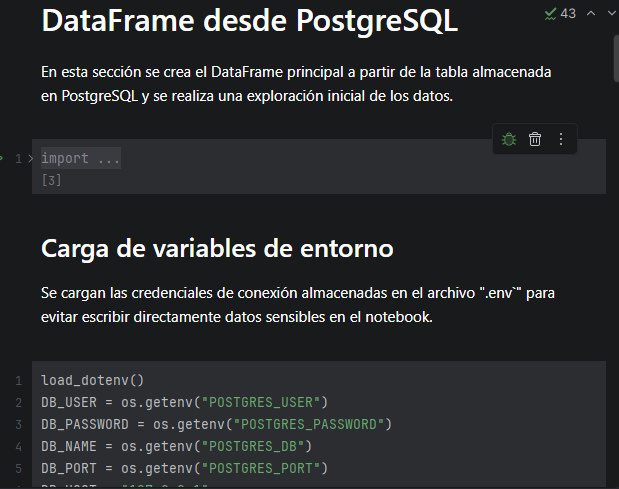


## 1. Configuración segura del proyecto

Para proteger información sensible, el proyecto utiliza variables de entorno almacenadas en un archivo `.env`. Esta práctica permite evitar que credenciales, rutas o parámetros sensibles queden escritos directamente en el notebook, reduciendo riesgos de seguridad y facilitando la portabilidad del proyecto.


In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

DB_USER = os.getenv("POSTGRES_USER")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
DB_NAME = os.getenv("POSTGRES_DB")
DB_PORT = os.getenv("POSTGRES_PORT")
DB_HOST = os.getenv("POSTGRES_HOST", "127.0.0.1")


## 2. Carga de las fuentes de datos

En esta etapa se cargan las tres fuentes utilizadas en el proyecto:
1. Archivo CSV
2. Archivo JSON
3. Tabla almacenada en PostgreSQL

In [2]:
df_csv = pd.read_csv("data/amazon_sale_report.csv", low_memory=False)
df_json = pd.read_json("data/amazon_sample.json")
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1"))
    print("Conexión exitosa:", result.scalar())

df_bd = pd.read_sql("SELECT * FROM public.sale_report", engine)

Conexión exitosa: 1



## 3. Exploración inicial de la fuente CSV

Se revisa la estructura general del archivo CSV para identificar dimensiones, tipos de datos, valores nulos, posibles duplicados y columnas relevantes para el proyecto.

In [3]:

print("Dimensiones CSV:", df_csv.shape)
print("\nTipos de datos CSV:")
print(df_csv.dtypes)

print("\nValores nulos CSV:")
print(df_csv.isnull().sum())

print("\nDuplicados CSV:")
print(df_csv.duplicated().sum())

df_csv.head()


Dimensiones CSV: (128975, 24)

Tipos de datos CSV:
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code      float64
ship-country              str
promotion-ids             str
B2B                      bool
fulfilled-by              str
Unnamed: 22            object
dtype: object

Valores nulos CSV:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN



## 4. Exploración inicial de la fuente JSON

Se analiza la estructura del archivo JSON y se identifican posibles problemas de valores faltantes, tipos de datos, duplicados y campos útiles para relacionar con las demás fuentes.


In [4]:
print("Dimensiones JSON:", df_json.shape)
print("\nTipos de datos JSON:")
print(df_json.dtypes)

print("\nValores nulos JSON:")
print(df_json.isnull().sum())

print("\nDuplicados JSON:")
print(df_json.duplicated().sum())

df_json.head()

Dimensiones JSON: (5000, 24)

Tipos de datos JSON:
index                          int64
Order ID                         str
Date                  datetime64[us]
Status                           str
Fulfilment                       str
Sales Channel                    str
ship-service-level               str
Style                            str
SKU                              str
Category                         str
Size                             str
ASIN                             str
Courier Status                   str
Qty                            int64
currency                         str
Amount                       float64
ship-city                        str
ship-state                       str
ship-postal-code             float64
ship-country                     str
promotion-ids                    str
B2B                             bool
fulfilled-by                     str
Unnamed: 22                  float64
dtype: object

Valores nulos JSON:
index                    0

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN



## 5. Exploración inicial de la fuente PostgreSQL

Se revisa la tabla almacenada en PostgreSQL para validar su estructura, tipos de datos, campos nulos, duplicados y posibles columnas relacionales útiles para la integración.


In [5]:
print("Dimensiones PostgreSQL:", df_bd.shape)
print("\nTipos de datos PostgreSQL:")
print(df_bd.dtypes)

print("\nValores nulos PostgreSQL:")
print(df_bd.isnull().sum())

print("\nDuplicados PostgreSQL:")
print(df_bd.duplicated().sum())

df_bd.head()

Dimensiones PostgreSQL: (9271, 7)

Tipos de datos PostgreSQL:
index           int64
SKU Code          str
Design No.        str
stock         float64
category          str
size              str
color             str
dtype: object

Valores nulos PostgreSQL:
index          0
SKU Code      83
Design No.    36
stock         36
category      45
size          36
color         45
dtype: int64

Duplicados PostgreSQL:
0


,index,SKU Code,Design No.,stock,category,size,color
0,0,AN201-RED-L,AN201,5.0,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.0,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.0,AN : LEGGINGS,S,Red
3,3,AN201-RED-XL,AN201,6.0,AN : LEGGINGS,XL,Red
4,4,AN201-RED-XXL,AN201,3.0,AN : LEGGINGS,XXL,Red



## 6. Funciones de limpieza y transformación

A continuación, se definen funciones reutilizables para mejorar la calidad de los datos. Estas funciones permitirán estandarizar nombres de columnas, eliminar duplicados, tratar valores nulos, normalizar texto y preparar claves de relación entre las fuentes.


In [6]:
def limpiar_nombres_columnas(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(" ", "_")
                  .str.replace("-", "_")
    )
    return df

def eliminar_duplicados(df):
    return df.drop_duplicates()

def normalizar_texto(df, columnas):
    df = df.copy()
    for col in columnas:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
    return df

def convertir_fechas(df, columnas):
    df = df.copy()
    for col in columnas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%m-%d-%y", errors="coerce")
    return df

def convertir_numerico(df, columnas):
    df = df.copy()
    for col in columnas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


## 7. Se aplica la limpieza a cada DataFrame

Para el CSV:

In [7]:
df_csv_limpio = limpiar_nombres_columnas(df_csv)
df_csv_limpio = eliminar_duplicados(df_csv_limpio)
df_csv_limpio = normalizar_texto(df_csv_limpio, ["status", "category", "size"])
df_csv_limpio = convertir_fechas(df_csv_limpio, ["date"])
df_csv_limpio = convertir_numerico(df_csv_limpio, ["amount"])


Para el JSON:

In [8]:
df_json_limpio = limpiar_nombres_columnas(df_json)
df_json_limpio = eliminar_duplicados(df_json_limpio)
df_json_limpio = normalizar_texto(df_json_limpio, ["status", "category", "size"])
df_json_limpio = convertir_fechas(df_json_limpio, ["date"])
df_json_limpio = convertir_numerico(df_json_limpio, ["amount"])

Para el PostgreSQL:

In [9]:
df_bd_limpio = limpiar_nombres_columnas(df_bd)
df_bd_limpio = eliminar_duplicados(df_bd_limpio)
df_bd_limpio = normalizar_texto(df_bd_limpio, ["category", "size"])


## 8. Selección de columnas relevantes

Se seleccionan únicamente las columnas necesarias para el proyecto. Se conservan aquellas que aportan información sobre pedidos, productos, categorías, fechas, estados y montos, y se eliminan columnas redundantes, vacías o no relevantes para el análisis y la integración.


In [10]:
columnas_relevantes = [
    "order_id", "date", "status", "category", "size", "sku", "amount"
]

df_csv_final = df_csv_limpio[[col for col in columnas_relevantes if col in df_csv_limpio.columns]]
df_json_final = df_json_limpio[[col for col in columnas_relevantes if col in df_json_limpio.columns]]
df_bd_final = df_bd_limpio[[col for col in df_bd_limpio.columns if col in ["sku_code", "design_no", "stock", "category", "size"]]]


## 9. Transformaciones aplicadas

### Creación de variables derivadas de fecha
A partir de la columna `date`, se generan las columnas `anio` y `mes` para facilitar análisis temporales y futuras agrupaciones.

### Categorización del monto de venta
Se crea la columna `tipo_venta` para clasificar los registros según el valor de `amount` en niveles de venta alta, media o baja.

### Normalización de claves de relación
Se estandariza la columna `sku` en las fuentes CSV y JSON con el fin de uniformar su formato y facilitar la relación entre ambas fuentes de datos.


In [11]:
df_csv_final["anio"] = df_csv_final["date"].dt.year
df_csv_final["mes"] = df_csv_final["date"].dt.month

df_csv_final["tipo_venta"] = df_csv_final["amount"].apply(
    lambda x: "sin_dato" if pd.isna(x) else "alta" if x >= 1000 else "media" if x >= 500 else "baja"
)

df_csv_final["sku"] = df_csv_final["sku"].astype(str).str.strip().str.upper()
df_json_final["sku"] = df_json_final["sku"].astype(str).str.strip().str.upper()


In [12]:
print("CSV SKU:")
print(df_csv_final[["sku"]].head())

print("\nJSON SKU:")
print(df_json_final[["sku"]].head())

print("\nNulos en amount:")
print(df_csv_final["amount"].isnull().sum())


CSV SKU:
               sku
0   SET389-KR-NP-S
1  JNE3781-KR-XXXL
2    JNE3371-KR-XL
3       J0341-DR-L
4  JNE3671-TU-XXXL

JSON SKU:
               sku
0   SET389-KR-NP-S
1  JNE3781-KR-XXXL
2    JNE3371-KR-XL
3       J0341-DR-L
4  JNE3671-TU-XXXL

Nulos en amount:
7795



## 10. Generación de identificadores

Con el fin de organizar mejor los datos y facilitar su futura integración, se generan identificadores numéricos únicos y secuenciales.

En primer lugar, se crea un identificador de registro para cada una de las fuentes transformadas, lo que permite mantener trazabilidad interna sobre cada fila procesada.

Adicionalmente, se construye un identificador de producto a partir de la columna `sku`, ya que esta se encuentra presente en las fuentes CSV y JSON y puede utilizarse como clave de relación entre ambas. Esta estrategia facilita la integración de los datos y mejora la consistencia en futuras uniones, análisis o cargas hacia un sistema de destino.


In [13]:
# Reiniciar índices para asegurar secuencia limpia
df_csv_final = df_csv_final.reset_index(drop=True)
df_json_final = df_json_final.reset_index(drop=True)

# Identificadores secuenciales por registro
df_csv_final["id_registro_csv"] = range(1, len(df_csv_final) + 1)
df_json_final["id_registro_json"] = range(1, len(df_json_final) + 1)

# Crear catálogo único de productos a partir de SKU
catalogo_productos = pd.DataFrame({
    "sku": pd.concat([df_csv_final["sku"], df_json_final["sku"]], ignore_index=True)
}).dropna().drop_duplicates().reset_index(drop=True)

# Identificador secuencial de producto
catalogo_productos["id_producto"] = range(1, len(catalogo_productos) + 1)

# Integrar el id_producto a cada fuente
df_csv_final = df_csv_final.merge(catalogo_productos, on="sku", how="left")
df_json_final = df_json_final.merge(catalogo_productos, on="sku", how="left")


In [14]:
print("Vista previa CSV con identificadores:")
display(df_csv_final[["id_registro_csv", "sku", "id_producto"]].head())

print("Vista previa JSON con identificadores:")
display(df_json_final[["id_registro_json", "sku", "id_producto"]].head())

print("Total de productos únicos:", catalogo_productos.shape[0])


Vista previa CSV con identificadores:


,id_registro_csv,sku,id_producto
0,1,SET389-KR-NP-S,1
1,2,JNE3781-KR-XXXL,2
2,3,JNE3371-KR-XL,3
3,4,J0341-DR-L,4
4,5,JNE3671-TU-XXXL,5


Vista previa JSON con identificadores:


,id_registro_json,sku,id_producto
0,1,SET389-KR-NP-S,1
1,2,JNE3781-KR-XXXL,2
2,3,JNE3371-KR-XL,3
3,4,J0341-DR-L,4
4,5,JNE3671-TU-XXXL,5


Total de productos únicos: 7195



## 11. Validación de resultados

Una vez aplicadas las funciones de limpieza, selección de columnas, transformaciones y generación de identificadores, se realiza una validación final de los resultados obtenidos.

En esta etapa se verifica:

- La estructura final de los DataFrames transformados.
- La presencia de valores nulos restantes.
- La existencia de registros duplicados.
- La consistencia de los tipos de datos.
- Una vista previa de los datos finales para confirmar que las transformaciones se aplicaron correctamente.

Esta validación permite comprobar que los datos quedan en mejores condiciones para futuras etapas de integración, análisis o carga dentro del proceso ETL.

In [15]:
print("========== VALIDACIÓN FINAL ==========")

# =========================
# Validación CSV
# =========================
print("\n--- DataFrame CSV transformado ---")
display(df_csv_final.head())

print("\nDimensiones CSV:", df_csv_final.shape)

print("\nValores nulos restantes en CSV:")
print(df_csv_final.isnull().sum())

print("\nDuplicados en CSV:", df_csv_final.duplicated().sum())

print("\nTipos de datos CSV:")
print(df_csv_final.dtypes)

# =========================
# Validación JSON
# =========================
print("\n--- DataFrame JSON transformado ---")
display(df_json_final.head())

print("\nDimensiones JSON:", df_json_final.shape)

print("\nValores nulos restantes en JSON:")
print(df_json_final.isnull().sum())

print("\nDuplicados en JSON:", df_json_final.duplicated().sum())

print("\nTipos de datos JSON:")
print(df_json_final.dtypes)

# =========================
# Validación PostgreSQL
# =========================
df_bd_validacion = df_bd_final if "df_bd_final" in globals() else df_bd_limpio

print("\n--- DataFrame PostgreSQL transformado ---")
display(df_bd_validacion.head())

print("\nDimensiones PostgreSQL:", df_bd_validacion.shape)

print("\nValores nulos restantes en PostgreSQL:")
print(df_bd_validacion.isnull().sum())

print("\nDuplicados en PostgreSQL:", df_bd_validacion.duplicated().sum())

print("\nTipos de datos PostgreSQL:")
print(df_bd_validacion.dtypes)


========== VALIDACIÓN FINAL ==========

--- DataFrame CSV transformado ---


,order_id,date,status,category,size,sku,amount,anio,mes,tipo_venta,id_registro_csv,id_producto
0,405-8078784-5731545,2022-04-30,cancelled,set,s,SET389-KR-NP-S,647.62,2022,4,media,1,1
1,171-9198151-1101146,2022-04-30,shipped - delivered to buyer,kurta,3xl,JNE3781-KR-XXXL,406.00,2022,4,baja,2,2
2,404-0687676-7273146,2022-04-30,shipped,kurta,xl,JNE3371-KR-XL,329.00,2022,4,baja,3,3
3,403-9615377-8133951,2022-04-30,cancelled,western dress,l,J0341-DR-L,753.33,2022,4,media,4,4
4,407-1069790-7240320,2022-04-30,shipped,top,3xl,JNE3671-TU-XXXL,574.00,2022,4,media,5,5



Dimensiones CSV: (128975, 12)

Valores nulos restantes en CSV:
order_id              0
date                  0
status                0
category              0
size                  0
sku                   0
amount             7795
anio                  0
mes                   0
tipo_venta            0
id_registro_csv       0
id_producto           0
dtype: int64

Duplicados en CSV: 0

Tipos de datos CSV:
order_id                      str
date               datetime64[us]
status                        str
category                      str
size                          str
sku                           str
amount                    float64
anio                        int32
mes                         int32
tipo_venta                    str
id_registro_csv             int64
id_producto                 int64
dtype: object

--- DataFrame JSON transformado ---


,order_id,date,status,category,size,sku,amount,id_registro_json,id_producto
0,405-8078784-5731545,2022-04-30,cancelled,set,s,SET389-KR-NP-S,647.62,1,1
1,171-9198151-1101146,2022-04-30,shipped - delivered to buyer,kurta,3xl,JNE3781-KR-XXXL,406.00,2,2
2,404-0687676-7273146,2022-04-30,shipped,kurta,xl,JNE3371-KR-XL,329.00,3,3
3,403-9615377-8133951,2022-04-30,cancelled,western dress,l,J0341-DR-L,753.33,4,4
4,407-1069790-7240320,2022-04-30,shipped,top,3xl,JNE3671-TU-XXXL,574.00,5,5



Dimensiones JSON: (5000, 9)

Valores nulos restantes en JSON:
order_id              0
date                  0
status                0
category              0
size                  0
sku                   0
amount              338
id_registro_json      0
id_producto           0
dtype: int64

Duplicados en JSON: 0

Tipos de datos JSON:
order_id                       str
date                datetime64[us]
status                         str
category                       str
size                           str
sku                            str
amount                     float64
id_registro_json             int64
id_producto                  int64
dtype: object

--- DataFrame PostgreSQL transformado ---


,sku_code,stock,category,size
0,AN201-RED-L,5.0,an : leggings,l
1,AN201-RED-M,5.0,an : leggings,m
2,AN201-RED-S,3.0,an : leggings,s
3,AN201-RED-XL,6.0,an : leggings,xl
4,AN201-RED-XXL,3.0,an : leggings,xxl



Dimensiones PostgreSQL: (9271, 4)

Valores nulos restantes en PostgreSQL:
sku_code    83
stock       36
category    45
size        36
dtype: int64

Duplicados en PostgreSQL: 67

Tipos de datos PostgreSQL:
sku_code        str
stock       float64
category        str
size            str
dtype: object


### Observaciones de validación

En la fuente CSV aún se identifican valores nulos en la columna `amount`. Sin embargo, estos registros fueron considerados durante la transformación mediante la creación de la categoría `sin_dato` en la columna `tipo_venta`, evitando así que los valores faltantes afecten la clasificación de los registros.

En general, los resultados de validación muestran que las fuentes fueron estandarizadas y preparadas adecuadamente para una futura integración dentro del proceso ETL.


## 12. Reflexión individual

### 12.1 Santiago Bravo


Esta semana aprendí que la transformación de datos es una etapa esencial dentro del proceso ETL, porque permite limpiar, normalizar, estructurar y validar la información antes de integrarla o analizarla. En un entorno profesional orientado a telecomunicaciones, redes e ISP, esta práctica puede ayudar a mejorar el tratamiento de datos como tickets de soporte, registros de tráfico, inventario de equipos, alarmas de red o reportes de consumo. En estos contextos suelen aparecer errores como valores nulos, formatos inconsistentes, códigos escritos de distintas maneras, duplicados o datos incompletos, lo que dificulta el análisis y la toma de decisiones.

Mediante funciones de limpieza y transformación se puede estandarizar nombres de columnas, normalizar claves, convertir tipos de datos, crear variables derivadas y clasificar registros para facilitar su uso posterior. Documentar cada paso en un notebook es importante porque permite entender qué se hizo, justificar las decisiones tomadas y dejar evidencia reproducible del proceso. Considero que esta práctica aporta valor porque mejora la calidad de la información disponible y permite tomar decisiones más confiables sobre operación, soporte, capacidad y control de servicios dentro de un entorno técnico.


### 12.2 Alexander Soto

La realización de esta práctica ayuda a comprender la importancia de los procesos ETL para extraer, transformar y cargar datos provenientes de diferentes fuentes, garantizando su calidad y disponibilidad para el análisis, se fortalecieron conocimientos relacionados con la limpieza, integración y almacenamiento de la información mediante herramientas como Python y PostgreSQL, evidenciando la relevancia de una adecuada gestión de datos dentro de las organizaciones.

Desde mi perspectiva como Analista SOC, estos conocimientos son de gran utilidad, ya que diariamente se procesan grandes volúmenes de eventos y registros provenientes de múltiples herramientas de seguridad.

La aplicación de procesos ETL facilita la consolidación y preparación de la información, permitiendo realizar análisis más eficientes, mejorar la detección de incidentes y apoyar la toma de decisiones orientadas a fortalecer la ciberseguridad de las organizaciones.

### 12.3 Yordhan Guerrón

La presente práctica permitió comprender de manera más profunda la importancia de los procesos ETL para la gestión y aprovechamiento de los datos dentro de una organización. A través del uso de Python, PostgreSQL y diferentes fuentes de información, fue posible aplicar técnicas de exploración, limpieza, transformación y validación de datos, garantizando una mejor calidad de la información antes de ser utilizada para análisis o toma de decisiones.

En mi entorno profesional, relacionado con el área comercial y de negociación de mercadería importada, se generan constantemente datos asociados a ventas, inventarios, órdenes de compra, proveedores, precios, promociones y comportamiento de productos. Con frecuencia, esta información proviene de diferentes sistemas o archivos, por lo que pueden existir inconsistencias, registros duplicados, formatos distintos o valores faltantes que dificultan su análisis.

Los conocimientos adquiridos en esta práctica pueden aplicarse para integrar información proveniente de múltiples fuentes y almacenarla de forma organizada en PostgreSQL, permitiendo realizar consultas más eficientes y mantener una base de datos centralizada. Adicionalmente, Docker facilita la implementación de entornos estandarizados y reproducibles para el desarrollo de soluciones de análisis de datos, mientras que Python permite automatizar tareas de limpieza, transformación y generación de reportes.

La implementación de un proceso ETL dentro de una organización aportaría beneficios importantes como la mejora en la calidad de los datos, la reducción de errores manuales, la integración de información dispersa y la disponibilidad de datos confiables para el análisis. Esto permitiría optimizar procesos operativos, mejorar el control de inventarios, identificar tendencias de ventas y evaluar el desempeño de productos o categorías específicas.

El análisis de la información obtenida podría apoyar decisiones estratégicas relacionadas con la planificación de compras, negociación con proveedores, gestión de inventarios y proyecciones de ventas. Asimismo, desde mi formación en ciberseguridad, estos conocimientos también resultan valiosos para procesar registros de eventos, detectar anomalías y fortalecer los procesos de monitoreo y gestión de incidentes. Por estas razones, considero que los conceptos aprendidos durante esta práctica constituyen una herramienta fundamental para mejorar la eficiencia operativa y la toma de decisiones basada en datos.